findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

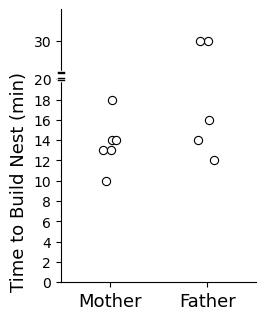

In [9]:
#mother and father data, time to build a nest
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

mother = [13, 14, 18, 14, 10, 13]
father = [30, 30, 12, 16, 14]

x_mother = np.zeros(len(mother))
x_father = np.ones(len(father))

fig = plt.figure(figsize=(3, 3.5))
ax_top = fig.add_axes([0.18, 0.72, 0.65, 0.18])
ax_bot = fig.add_axes([0.18, 0.12, 0.65, 0.58])

for ax, ylim, yticks in [
    (ax_top, (27, 33), [30]),
    (ax_bot, (0, 20),  np.arange(0, 21, 2))
]:
    jitter_m = np.random.uniform(-0.1, 0.1, len(mother))
    jitter_f = np.random.uniform(-0.1, 0.1, len(father))

    for i, val in enumerate(mother):
        ax.scatter(x_mother[i] + jitter_m[i], val,
                   color='white', edgecolors='black',
                   linewidths=0.8, s=35, zorder=3)
    for i, val in enumerate(father):
        ax.scatter(x_father[i] + jitter_f[i], val,
                   color='white', edgecolors='black',
                   linewidths=0.8, s=35, zorder=3)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

ax_bot.set_xticks([0, 1])
ax_bot.set_xticklabels(['Mother', 'Father'], fontsize=13)
ax_bot.set_ylabel('Time to Build Nest (min)', fontsize=13)

d = 0.013
gap_y = 0.004

for ax, y_pos in [(ax_top, 0), (ax_bot, 1)]:
    trans = ax.transAxes
    for dy in [-gap_y, +gap_y]:
        line = plt.Line2D(
            [-d, d], [y_pos + dy, y_pos + dy],
            transform=trans, color='w', linewidth=2.5,
            clip_on=False, zorder=10
        )
        ax.add_line(line)
        line = plt.Line2D(
            [-d, d], [y_pos + dy, y_pos + dy],
            transform=trans, color='k', linewidth=1,
            clip_on=False, zorder=11
        )
        ax.add_line(line)

#plt.savefig("nest_building_wt_mother_father.pdf", bbox_inches="tight")
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42


def broken_axis_scatter(
    groups: dict,
    ylabel: str = "Value",
    figsize: tuple = None,
    jitter_width: float = 0.1,
    marker_size: int = 35,
    gap_threshold: float = 0.3,   # fraction of total range to trigger a break
    break_padding: float = 1.5,   # padding around each cluster (in data units)
    save_path: str = None,
):
    """
    Broken-axis scatter plot for any number of groups.

    Parameters
    ----------
    groups : dict
        Mapping of group label -> list/array of values.
        e.g. {"Mother": [13,14,18], "Father": [30,30,12]}
    ylabel : str
        Y-axis label.
    figsize : tuple, optional
        Figure size. Defaults to (2 + 0.6*n_groups, 3.5).
    jitter_width : float
        Half-width of horizontal jitter applied to each point.
    marker_size : int
        Scatter marker size (s= argument).
    gap_threshold : float
        Fraction of the total data range that, when exceeded by a gap
        between value clusters, triggers a break. Lower = more breaks.
    break_padding : float
        Extra space (data units) added above/below each cluster window.
    save_path : str, optional
        If given, saves the figure to this path instead of showing it.
    """
    labels = list(groups.keys())
    all_values = np.concatenate([np.asarray(v) for v in groups.values()])
    n_groups = len(labels)

    # ------------------------------------------------------------------
    # Detect clusters of values separated by large gaps
    # ------------------------------------------------------------------
    sorted_vals = np.sort(np.unique(all_values))
    total_range = sorted_vals[-1] - sorted_vals[0] if len(sorted_vals) > 1 else 1
    min_gap = gap_threshold * total_range

    # Build clusters: list of (low, high) pairs in data space
    clusters = []
    cluster_start = sorted_vals[0]
    prev = sorted_vals[0]
    for v in sorted_vals[1:]:
        if v - prev > min_gap:
            clusters.append((cluster_start - break_padding,
                             prev + break_padding))
            cluster_start = v
        prev = v
    clusters.append((cluster_start - break_padding, prev + break_padding))

    n_panels = len(clusters)

    # ------------------------------------------------------------------
    # Figure layout — panels sized proportionally to their data range
    # ------------------------------------------------------------------
    if figsize is None:
        figsize = (2 + 0.6 * n_groups, 3.5)

    fig = plt.figure(figsize=figsize)

    left   = 0.22
    right  = 0.90
    bottom = 0.14
    top    = 0.94
    gap    = 0.06          # vertical gap between panels

    total_height = top - bottom - gap * (n_panels - 1)
    spans = [c[1] - c[0] for c in clusters]
    total_span = sum(spans)
    heights = [s / total_span * total_height for s in spans]

    axes = []
    y_cursor = bottom
    for i, (cluster, h) in enumerate(zip(clusters, heights)):
        ax = fig.add_axes([left, y_cursor, right - left, h])
        ax.set_ylim(*cluster)
        axes.append(ax)
        y_cursor += h + gap

    axes = axes[::-1]   # top panel first, bottom panel last
    clusters = clusters[::-1]

    # ------------------------------------------------------------------
    # Plot data on every panel (only visible points will show)
    # ------------------------------------------------------------------
    rng = np.random.default_rng(0)  # reproducible jitter

    for ax, (ylo, yhi) in zip(axes, clusters):
        for xi, (label, vals) in enumerate(groups.items()):
            vals = np.asarray(vals)
            jitter = rng.uniform(-jitter_width, jitter_width, len(vals))
            ax.scatter(
                xi + jitter, vals,
                color='white', edgecolors='black',
                linewidths=0.8, s=marker_size, zorder=3,
            )

        ax.set_xlim(-0.5, n_groups - 0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # ------------------------------------------------------------------
    # Spine / tick cosmetics
    # ------------------------------------------------------------------
    for i, ax in enumerate(axes):
        is_bottom = (i == len(axes) - 1)
        is_top    = (i == 0)

        if not is_top:
            ax.spines['top'].set_visible(False)
        if not is_bottom:
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(bottom=False, labelbottom=False)

        if is_bottom:
            ax.set_xticks(range(n_groups))
            ax.set_xticklabels(labels, fontsize=12)
        else:
            ax.tick_params(bottom=False, labelbottom=False)

    # Y-axis label on the middle panel
    mid_ax = axes[len(axes) // 2]
    mid_ax.set_ylabel(ylabel, fontsize=12)

    # ------------------------------------------------------------------
    # Break marks (diagonal slash lines between panels)
    # ------------------------------------------------------------------
    d       = 0.013
    gap_y   = 0.004

    def _draw_break(ax, y_pos):
        trans = ax.transAxes
        for dy in [-gap_y, +gap_y]:
            for color, lw, zorder in [('white', 2.5, 10), ('black', 1.0, 11)]:
                line = plt.Line2D(
                    [-d, d], [y_pos + dy, y_pos + dy],
                    transform=trans, color=color, linewidth=lw,
                    clip_on=False, zorder=zorder,
                )
                ax.add_line(line)

    for i in range(n_panels - 1):
        _draw_break(axes[i],     0)   # bottom edge of upper panel
        _draw_break(axes[i + 1], 1)   # top edge of lower panel

    # ------------------------------------------------------------------
    # Save or show
    # ------------------------------------------------------------------
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved to {save_path}")
    else:
        plt.show()

    return fig, axes

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

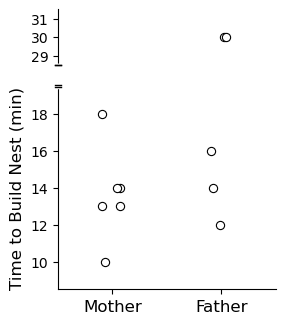

(<Figure size 320x350 with 2 Axes>,
 [<Axes: >, <Axes: ylabel='Time to Build Nest (min)'>])

In [11]:
 broken_axis_scatter(
        groups={
            "Mother": [13, 14, 18, 14, 10, 13],
            "Father": [30, 30, 12, 16, 14],
        },
        ylabel="Time to Build Nest (min)",
    )

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

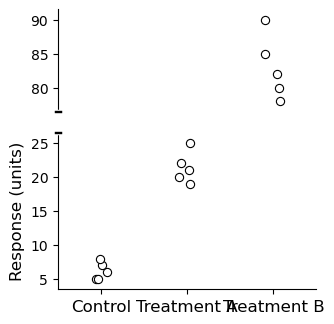

(<Figure size 380x350 with 2 Axes>,
 [<Axes: >, <Axes: ylabel='Response (units)'>])

In [12]:
    broken_axis_scatter(
        groups={
            "Control": [5, 6, 7, 5, 8],
            "Treatment A": [20, 22, 19, 25, 21],
            "Treatment B": [80, 85, 78, 90, 82],
        },
        ylabel="Response (units)",
        gap_threshold=0.25,
    )